googleplaystore_ratings_reviews_9367.csv already exists.
File size: 85569 bytes
First 10 lines of the downloaded file:
Rating,Reviews
4.1,159
3.9,967
4.7,87510
4.5,215644
4.3,967
4.4,167
3.8,178
4.1,36815
4.4,13791
Shape of the loaded new dataset: (9367, 2)

NaN counts after loading new dataset:
Rating     0
Reviews    0
dtype: int64

Shape after final cleaning steps: (9367, 2)

NaN counts after final cleaning steps:
Rating     0
Reviews    0
dtype: int64

Overall Correlation (All Apps, New Dataset): 0.0681
-> As expected, higher ratings generally trend with more reviews globally.
--------------------------------------------------
Filtered Correlation (Top 10% for Rating OR Reviews, New Dataset): -0.2947
-> Berkson's Paradox! The correlation flips to negative among the elite subset.


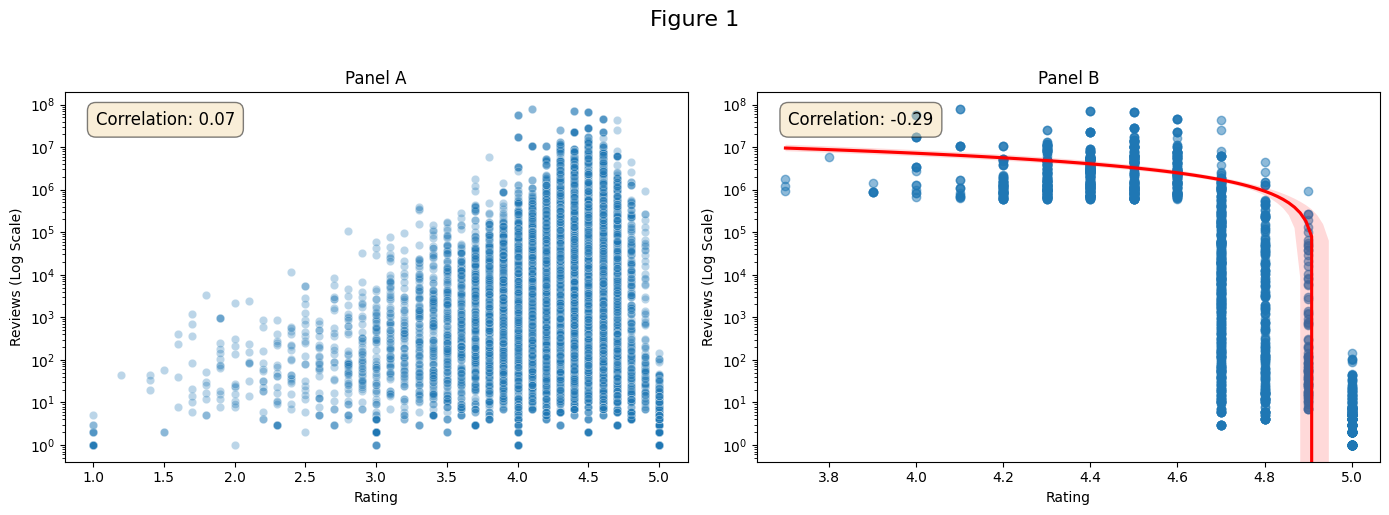

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_path = '/content/googleplaystore_ratings_reviews_9367.csv'
file_url = 'https://raw.githubusercontent.com/google-research/colab-sample-data/main/googleplaystore_ratings_reviews_9367.csv'

if not os.path.exists(file_path):
    print(f"Downloading {os.path.basename(file_path)}...")
    !wget -q $file_url -O $file_path
    print("Download complete.")
else:
    print(f"{os.path.basename(file_path)} already exists.")

if os.path.exists(file_path):
    print(f"File size: {os.path.getsize(file_path)} bytes")
    print("First 10 lines of the downloaded file:")
    !head -n 10 $file_path
else:
    print("Error: File was not downloaded.")

df = pd.read_csv(file_path)

print(f"Shape of the loaded new dataset: {df.shape}")
print("\nNaN counts after loading new dataset:")
print(df[['Rating', 'Reviews']].isnull().sum())

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

df = df.dropna(subset=['Reviews'])

print(f"\nShape after final cleaning steps: {df.shape}")
print("\nNaN counts after final cleaning steps:")
print(df[['Rating', 'Reviews']].isnull().sum())

overall_corr = df['Rating'].corr(df['Reviews'])
print(f"\nOverall Correlation (All Apps, New Dataset): {overall_corr:.4f}")
print("-> As expected, higher ratings generally trend with more reviews globally.")

print("-" * 50)

top_tier_df = df[(df['Rating'] >= df['Rating'].quantile(0.90)) | (df['Reviews'] >= df['Reviews'].quantile(0.90))].copy()

top_tier_corr = top_tier_df['Rating'].corr(top_tier_df['Reviews'])
print(f"Filtered Correlation (Top 10% for Rating OR Reviews, New Dataset): {top_tier_corr:.4f}")
print("-> Berkson's Paradox! The correlation flips to negative among the elite subset.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1', fontsize=16, y=1.02)

sns.scatterplot(data=df, x='Rating', y='Reviews', alpha=0.3, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Panel A')
axes[0].set_ylabel('Reviews (Log Scale)')
axes[0].text(0.05, 0.95, f'Correlation: {overall_corr:.2f}', transform=axes[0].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

sns.regplot(data=top_tier_df, x='Rating', y='Reviews', ax=axes[1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_yscale('log')
axes[1].set_title('Panel B')
axes[1].set_ylabel('Reviews (Log Scale)')
axes[1].text(0.05, 0.95, f'Correlation: {top_tier_corr:.2f}', transform=axes[1].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

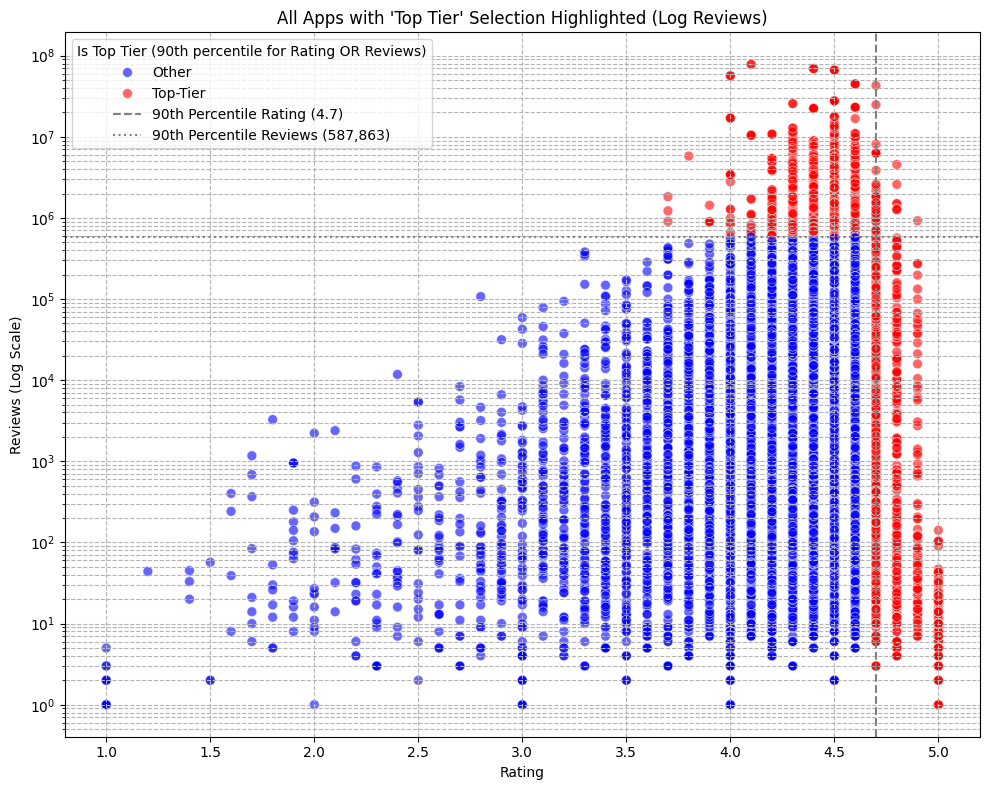

In [19]:
plt.figure(figsize=(10, 8))

rating_90th_percentile = df['Rating'].quantile(0.90)
reviews_90th_percentile = df['Reviews'].quantile(0.90)

df['is_top_tier'] = (df['Rating'] >= rating_90th_percentile) | (df['Reviews'] >= reviews_90th_percentile)

sns.scatterplot(data=df, x='Rating', y='Reviews', hue='is_top_tier',
                palette={True: 'red', False: 'blue'},
                alpha=0.6, s=50,
                hue_order=[False, True])

plt.axvline(x=rating_90th_percentile, color='gray', linestyle='--', label=f'90th Percentile Rating ({rating_90th_percentile:.1f})')
plt.axhline(y=reviews_90th_percentile, color='gray', linestyle=':', label=f'90th Percentile Reviews ({reviews_90th_percentile:,.0f})')

plt.yscale('log')
plt.title("All Apps with 'Top Tier' Selection Highlighted (Log Reviews)")
plt.xlabel('Rating')
plt.ylabel('Reviews (Log Scale)')

handles, current_labels = plt.gca().get_legend_handles_labels()

new_labels_map = {'False': 'Other', 'True': 'Top-Tier'}
updated_labels = [new_labels_map.get(label, label) for label in current_labels]

plt.legend(handles=handles, labels=updated_labels, title='Is Top Tier (90th percentile for Rating OR Reviews)')
plt.grid(True, which="both", ls="--", c='0.70')
plt.tight_layout()
plt.show()

df = df.drop(columns=['is_top_tier'])

In [20]:
print(f"Rating 90th Percentile: {rating_90th_percentile}")
print(f"Reviews 90th Percentile: {reviews_90th_percentile}")

Rating 90th Percentile: 4.7
Reviews 90th Percentile: 587863.1999999979


In [16]:
top_tier_df.to_csv('googleplaystore_top_tier.csv', index=False)

print("Successfully saved 'top_tier_df' to 'googleplaystore_top_tier.csv'.")

Successfully saved 'top_tier_df' to 'googleplaystore_top_tier.csv'.
